In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import matplotlib
import keras
import matplotlib.pyplot as plt


I0000 00:00:1775024460.326049   29384 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775024460.369329   29384 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775024461.679034   29384 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
from keras.models import Sequential
from keras.layers import Dense, Input
from keras import optimizers
from sklearn import model_selection
from keras import regularizers
from datetime import datetime

In [4]:
df = pd.read_csv("data/blood_cell_anomaly_detection.csv")
df

,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,...,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,CELL_005371,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,...,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,CELL_005300,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,...,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,CELL_000200,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,...,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,CELL_003269,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,...,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,CELL_003505,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,...,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5875,CELL_003773,Platelet,0,Normal_Platelet,2.30,0.0,0.000,1.000,0.699,0.536,...,81.4,34.2,CytoData,May_Grunwald_Giemsa,Olympus_BX51,40,360,0.1178,1.0000,0.8849
5876,CELL_005192,Target_Cell,1,Anemia,8.80,0.0,0.000,1.000,0.831,0.199,...,88.1,34.4,Raabin_WBC,Giemsa,Zeiss_Axio,40,224,0.9034,0.9475,0.5928
5877,CELL_005227,Target_Cell,1,Anemia,9.57,0.0,0.000,1.000,0.900,0.320,...,86.7,34.0,PBC_Dataset,Giemsa,Olympus_BX51,40,256,0.8493,0.6716,0.6381
5878,CELL_005391,Hypersegmented_Neutrophil,1,Infection,11.98,67.8,0.528,0.309,0.752,0.505,...,96.5,32.9,CytoData,Giemsa,Leica_DM2000,100,256,0.9004,0.6449,0.8801


In [5]:
print("Shape original:", df.shape)
print("\nDistribuição do target (anomaly_label):")
print(df['anomaly_label'].value_counts())
print(f"\nProporção: {df['anomaly_label'].value_counts(normalize=True).round(3).to_dict()}")

Shape original: (5880, 36)

Distribuição do target (anomaly_label):
anomaly_label
0    4000
1    1880
Name: count, dtype: int64

Proporção: {0: 0.68, 1: 0.32}


In [6]:
colunas_remover = [
    'cell_id',
    'cell_type',
    'disease_category',
    'cytodiffusion_anomaly_score',
    'cytodiffusion_classification_confidence',
    'labeller_confidence_score',
    'dataset_source',
    'staining_protocol',
    'microscope_model',
    'magnification_x',
    'image_resolution_px'
]
 
df = df.drop(columns=colunas_remover)
print("\nColunas após remoção:", df.shape[1])
print(df.columns.tolist())


Colunas após remoção: 25
['anomaly_label', 'cell_diameter_um', 'nucleus_area_pct', 'chromatin_density', 'cytoplasm_ratio', 'circularity', 'eccentricity', 'granularity_score', 'lobularity_score', 'membrane_smoothness', 'cell_area_px', 'perimeter_px', 'mean_r', 'mean_g', 'mean_b', 'stain_intensity', 'patient_age_group', 'patient_sex', 'wbc_count_per_ul', 'rbc_count_millions_per_ul', 'hemoglobin_g_dl', 'hematocrit_pct', 'platelet_count_per_ul', 'mcv_fl', 'mchc_g_dl']


In [7]:
nulos = df.isnull().sum()
print("\nValores nulos por coluna:")
print(nulos[nulos > 0] if nulos.sum() > 0 else "Nenhum valor nulo encontrado.")


Valores nulos por coluna:
Nenhum valor nulo encontrado.


In [8]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

le_sex = LabelEncoder()
df['patient_sex'] = le_sex.fit_transform(df['patient_sex'])
print("\nEncoding patient_sex:", dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_))))

age_order = {'Pediatric': 0, 'Adult': 1, 'Elderly': 2}
df['patient_age_group'] = df['patient_age_group'].map(age_order)
print("Encoding patient_age_group:", age_order)


Encoding patient_sex: {'F': np.int64(0), 'M': np.int64(1)}
Encoding patient_age_group: {'Pediatric': 0, 'Adult': 1, 'Elderly': 2}


In [9]:
X = df.drop(columns=['anomaly_label'])
y = df['anomaly_label']
 
d = X.shape[1]
N = X.shape[0]
 
print(f"\nNúmero de amostras (N): {N}")
print(f"Número de features (d): {d}")
print(f"\nFeatures utilizadas:\n{X.columns.tolist()}")


Número de amostras (N): 5880
Número de features (d): 24

Features utilizadas:
['cell_diameter_um', 'nucleus_area_pct', 'chromatin_density', 'cytoplasm_ratio', 'circularity', 'eccentricity', 'granularity_score', 'lobularity_score', 'membrane_smoothness', 'cell_area_px', 'perimeter_px', 'mean_r', 'mean_g', 'mean_b', 'stain_intensity', 'patient_age_group', 'patient_sex', 'wbc_count_per_ul', 'rbc_count_millions_per_ul', 'hemoglobin_g_dl', 'hematocrit_pct', 'platelet_count_per_ul', 'mcv_fl', 'mchc_g_dl']


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"\nTamanho do conjunto de treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de teste:  {X_test.shape[0]} amostras")
print(f"Tamanho do conjunto de validação:  {X_val.shape[0]} amostras")
print(f"\nDistribuição no treino:\n{y_train.value_counts()}")
print(f"\nDistribuição no teste:\n{y_test.value_counts()}")
print(f"\nDistribuição na validação:\n{y_val.value_counts()}")


Tamanho do conjunto de treino: 4116 amostras
Tamanho do conjunto de teste:  882 amostras
Tamanho do conjunto de validação:  882 amostras

Distribuição no treino:
anomaly_label
0    2800
1    1316
Name: count, dtype: int64

Distribuição no teste:
anomaly_label
0    600
1    282
Name: count, dtype: int64

Distribuição na validação:
anomaly_label
0    600
1    282
Name: count, dtype: int64


In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.copy())
X_test = scaler.transform(X_test.copy())
X_val = scaler.transform(X_val.copy())
 
# Convertendo de volta para DataFrame para facilitar visualização
X_train= pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test,  columns=X.columns)
X_val = pd.DataFrame(X_val,  columns=X.columns)

print("\nVerificação após padronização (treino) — primeiras 5 features:")
print(X_train.describe().T[['mean', 'std']].round(4).head(5))


Verificação após padronização (treino) — primeiras 5 features:
                   mean     std
cell_diameter_um   -0.0  1.0001
nucleus_area_pct   -0.0  1.0001
chromatin_density  -0.0  1.0001
cytoplasm_ratio     0.0  1.0001
circularity        -0.0  1.0001


In [12]:
CT = X_train.shape[0]
n_max = int((CT - 10) / (10 * (d + 2)))
 
print(f"\n--- Regra de Ouro (Teoria da Generalização) ---")
print(f"|CT| = {CT}, d = {d}")
print(f"n_max = floor(({CT} - 10) / (10 * ({d} + 2)))")
print(f"n_max = floor({CT - 10} / {10 * (d + 2)})")
print(f"n_max = {n_max} neurônios na camada escondida")


--- Regra de Ouro (Teoria da Generalização) ---
|CT| = 4116, d = 24
n_max = floor((4116 - 10) / (10 * (24 + 2)))
n_max = floor(4106 / 260)
n_max = 15 neurônios na camada escondida


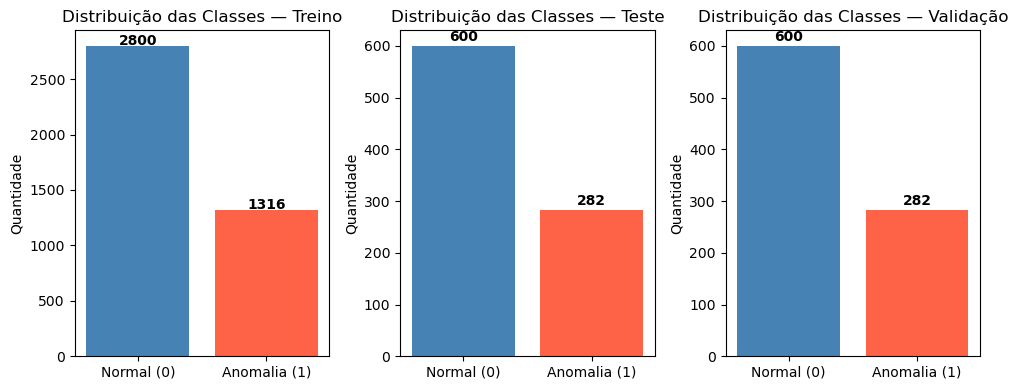


✅ Pré-processamento concluído!
   X_train_scaled: (4116, 24)
   X_test_scaled:  (882, 24)
   X_val_scaled:  (882, 24)


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
 
for ax, (data, title) in zip(axes, [
    (y_train, 'Treino'),
    (y_test,  'Teste'),
    (y_val, 'Validação')
]):
    counts = data.value_counts()
    ax.bar(['Normal (0)', 'Anomalia (1)'], counts.values,
           color=['steelblue', 'tomato'])
    ax.set_title(f'Distribuição das Classes — {title}')
    ax.set_ylabel('Quantidade')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
 
plt.tight_layout()
plt.show()
 
print("\n✅ Pré-processamento concluído!")
print(f"   X_train_scaled: {X_train.shape}")
print(f"   X_test_scaled:  {X_test.shape}")
print(f"   X_val_scaled:  {X_val.shape}")

In [14]:
model = Sequential()

model.add(Input(shape=(24,)))

model.add(Dense(15, kernel_initializer='he_uniform', activation='relu'))
model.add(Dense(1, kernel_initializer='glorot_uniform', activation='sigmoid'))

initial_weights = model.get_weights()

sgd = optimizers.SGD(learning_rate=0.01)

model.compile(loss='binary_crossentropy', optimizer=sgd, metrics=['accuracy', 'AUC'])

print(model.summary())

E0000 00:00:1775024462.409687   29384 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1775024462.410157   45200 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1775024462.427383   29384 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 15)             │           375 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391 (1.53 KB)

 Trainable params: 391 (1.53 KB)

 Non-trainable params: 0 (0.00 B)

None


In [15]:
model.set_weights(initial_weights)

history = model.fit(X_train, y_train, epochs=100, batch_size=16,
                   validation_data=(X_val, y_val))

Epoch 1/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - AUC: 0.5991 - accuracy: 0.6130 - loss: 0.6852 - val_AUC: 0.6492 - val_accuracy: 0.7177 - val_loss: 0.5940
Epoch 2/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.7292 - accuracy: 0.7641 - loss: 0.5403 - val_AUC: 0.7510 - val_accuracy: 0.7721 - val_loss: 0.5210
Epoch 3/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.7900 - accuracy: 0.8054 - loss: 0.4856 - val_AUC: 0.7970 - val_accuracy: 0.8118 - val_loss: 0.4756
Epoch 4/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.8188 - accuracy: 0.8236 - loss: 0.4490 - val_AUC: 0.8265 - val_accuracy: 0.8254 - val_loss: 0.4403
Epoch 5/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8370 - accuracy: 0.8377 - loss: 0.4209 - val_AUC: 0.8439 - val_accuracy: 0.8413 - val_loss: 0.4154
Epoch 6/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.8505 - accuracy: 0.8496 - loss: 0.3994 - val_AUC: 0.8562 - val_accuracy: 0.8469 - val_loss: 0.3951
Epoch 7/100
258/258 ━━━━━━━━━━━━━━

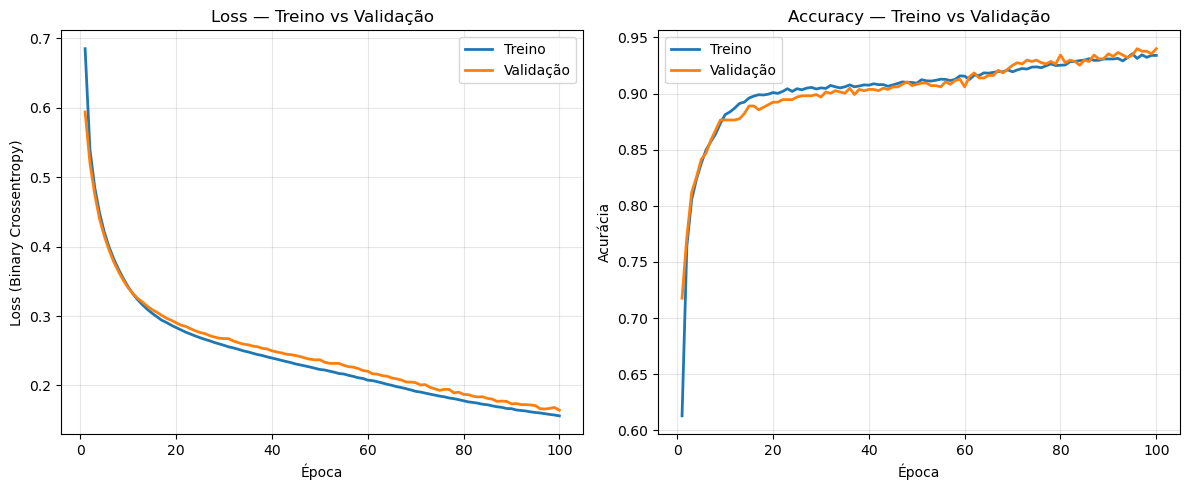


Menor val_loss em: época 100
Loss treino: 0.1562
Loss validação: 0.1644

Sem overfitting evidente


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Loss
ein  = history.history['loss']
eout = history.history.get('val_loss')  # evita erro

epocas = range(1, len(ein) + 1)

plt.figure(figsize=(12, 5))

# --- LOSS ---
plt.subplot(1, 2, 1)
plt.plot(epocas, ein, label='Treino', linewidth=2)
if eout is not None:
    plt.plot(epocas, eout, label='Validação', linewidth=2)

plt.xlabel('Época')
plt.ylabel('Loss (Binary Crossentropy)')
plt.title('Loss — Treino vs Validação')
plt.legend()
plt.grid(alpha=0.3)

# --- ACCURACY ---
acc  = history.history.get('accuracy')
val_acc = history.history.get('val_accuracy')

plt.subplot(1, 2, 2)
if acc is not None:
    plt.plot(epocas, acc, label='Treino', linewidth=2)
if val_acc is not None:
    plt.plot(epocas, val_acc, label='Validação', linewidth=2)

plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Accuracy — Treino vs Validação')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------
# DETECÇÃO DE OVERFITTING
# -----------------------------
if eout is not None:
    melhor_epoca = int(np.argmin(eout)) + 1

    print(f"\nMenor val_loss em: época {melhor_epoca}")
    print(f"Loss treino: {ein[melhor_epoca-1]:.4f}")
    print(f"Loss validação: {eout[melhor_epoca-1]:.4f}")

    if eout[-1] > eout[melhor_epoca-1]:
        print(f"\nOverfitting detectado a partir da época {melhor_epoca}")
    else:
        print(f"\nSem overfitting evidente")

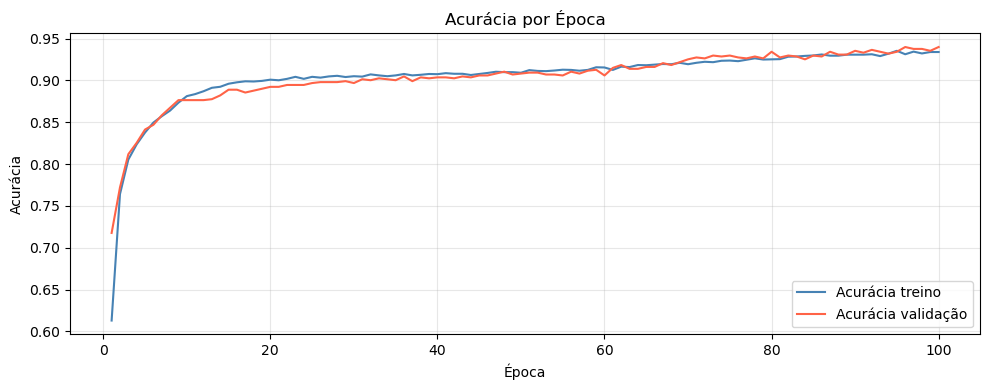

In [18]:
acc_train = history.history['accuracy']
acc_val   = history.history['val_accuracy']
 
plt.figure(figsize=(10, 4))
plt.plot(epocas, acc_train, label='Acurácia treino',    color='steelblue')
plt.plot(epocas, acc_val,   label='Acurácia validação', color='tomato')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Acurácia por Época')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
model.set_weights(initial_weights)

history = model.fit(X_train, y_train, epochs=150, batch_size=16,
                   validation_data=(X_val, y_val))

Epoch 1/150


258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.5952 - accuracy: 0.6152 - loss: 0.6863 - val_AUC: 0.6527 - val_accuracy: 0.7188 - val_loss: 0.5926
Epoch 2/150
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.7313 - accuracy: 0.7621 - loss: 0.5396 - val_AUC: 0.7546 - val_accuracy: 0.7744 - val_loss: 0.5199
Epoch 3/150
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.7895 - accuracy: 0.8044 - loss: 0.4854 - val_AUC: 0.7996 - val_accuracy: 0.8073 - val_loss: 0.4738
Epoch 4/150
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.8187 - accuracy: 0.8241 - loss: 0.4484 - val_AUC: 0.8264 - val_accuracy: 0.8231 - val_loss: 0.4402
Epoch 5/150
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.8369 - accuracy: 0.8394 - loss: 0.4209 - val_AUC: 0.8441 - val_accuracy: 0.8367 - val_loss: 0.4147
Epoch 6/150
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.8506 - accuracy: 0.8477 - loss: 0.3993 - val_AUC: 0.8576 - val_accuracy: 0.8481 - val_loss: 0.3945
Epoch 7/150
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1m

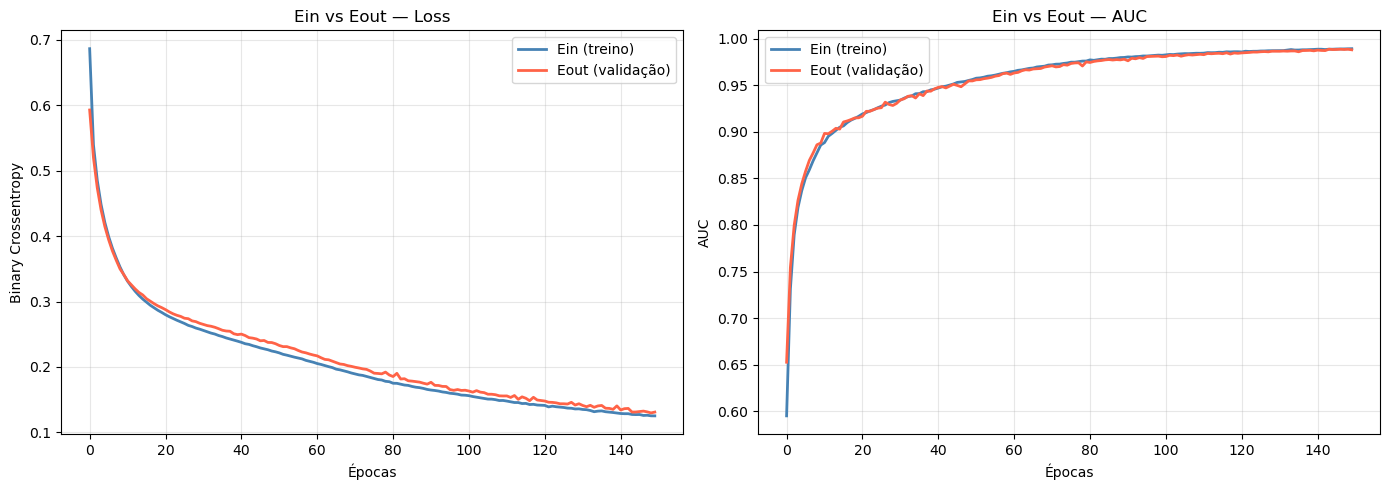


Melhor época (menor val_loss): 149
val_loss nessa época: 0.1298
loss nessa época:     0.1253

Época final (150):
  Ein  (loss treino):     0.1253
  Eout (loss validação):  0.1310
  Diferença Eout - Ein:   0.0058
  ✅ Sem overfitting significativo.


In [28]:
# -------------------------------------------------------------
# GRÁFICO Ein vs Eout (Loss e AUC por época)
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss ---
axes[0].plot(history.history['loss'],     label='Ein (treino)',     color='steelblue', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Eout (validação)', color='tomato',    linewidth=2)
axes[0].set_title('Ein vs Eout — Loss')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- AUC ---
axes[1].plot(history.history['AUC'],     label='Ein (treino)',     color='steelblue', linewidth=2)
axes[1].plot(history.history['val_AUC'], label='Eout (validação)', color='tomato',    linewidth=2)
axes[1].set_title('Ein vs Eout — AUC')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# IDENTIFICAR PONTO DE OVERFITTING (se houver)
# -------------------------------------------------------------
val_loss = history.history['val_loss']
min_val_loss = min(val_loss)
best_epoch = val_loss.index(min_val_loss) + 1

print(f"\nMelhor época (menor val_loss): {best_epoch}")
print(f"val_loss nessa época: {min_val_loss:.4f}")
print(f"loss nessa época:     {history.history['loss'][best_epoch-1]:.4f}")

train_loss_final = history.history['loss'][-1]
val_loss_final   = history.history['val_loss'][-1]
diff = val_loss_final - train_loss_final

print(f"\nÉpoca final ({len(val_loss)}):")
print(f"  Ein  (loss treino):     {train_loss_final:.4f}")
print(f"  Eout (loss validação):  {val_loss_final:.4f}")
print(f"  Diferença Eout - Ein:   {diff:.4f}")

if diff > 0.05:
    print("  ⚠️  Possível overfitting detectado.")
else:
    print("  ✅ Sem overfitting significativo.")

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
=== Métricas da Rede Neural ===
              precision    recall  f1-score   support

  Normal (0)       0.95      0.98      0.96       600
Anomalia (1)       0.95      0.88      0.92       282

    accuracy                           0.95       882
   macro avg       0.95      0.93      0.94       882
weighted avg       0.95      0.95      0.95       882



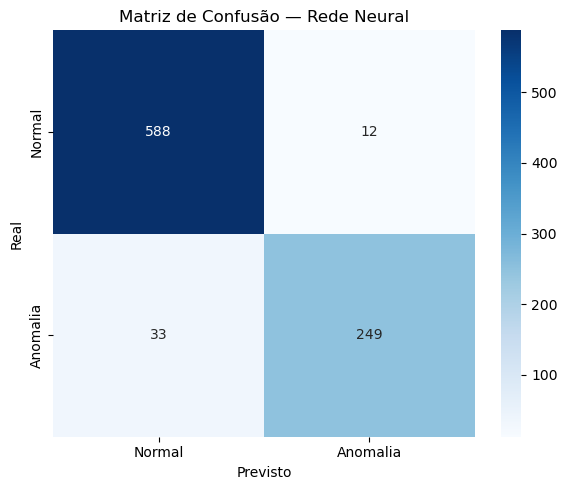

In [29]:
from sklearn.metrics import classification_report, confusion_matrix

# Predições na validação
y_pred_prob = model.predict(X_val)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Métricas
print("=== Métricas da Rede Neural ===")
print(classification_report(y_val, y_pred,
      target_names=['Normal (0)', 'Anomalia (1)']))

# Matriz de confusão
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomalia'],
            yticklabels=['Normal', 'Anomalia'])
plt.title('Matriz de Confusão — Rede Neural')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.tight_layout()
plt.show()

In [30]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# -------------------------------------------------------------
# ETAPA 1 — Árvore sem restrições (sem poda)
# -------------------------------------------------------------
tree_full = DecisionTreeClassifier(random_state=42)
tree_full.fit(X_train, y_train)

# Ein e Eout
ein_tree  = 1 - tree_full.score(X_train, y_train)
eout_tree = 1 - tree_full.score(X_val,   y_val)

print(f"Árvore sem poda:")
print(f"  Profundidade máxima: {tree_full.get_depth()}")
print(f"  Número de folhas:    {tree_full.get_n_leaves()}")
print(f"  Ein  (treino):       {ein_tree:.4f}")
print(f"  Eout (validação):    {eout_tree:.4f}")
print(f"  Diferença:           {eout_tree - ein_tree:.4f}")

Árvore sem poda:
  Profundidade máxima: 24
  Número de folhas:    178
  Ein  (treino):       0.0000
  Eout (validação):    0.0680
  Diferença:           0.0680


Número de alphas candidatos: 104
Range de alpha: 0.000000 até 0.046558

Melhor alpha: 0.001847
Acurácia CV:  0.9342 ± 0.0012


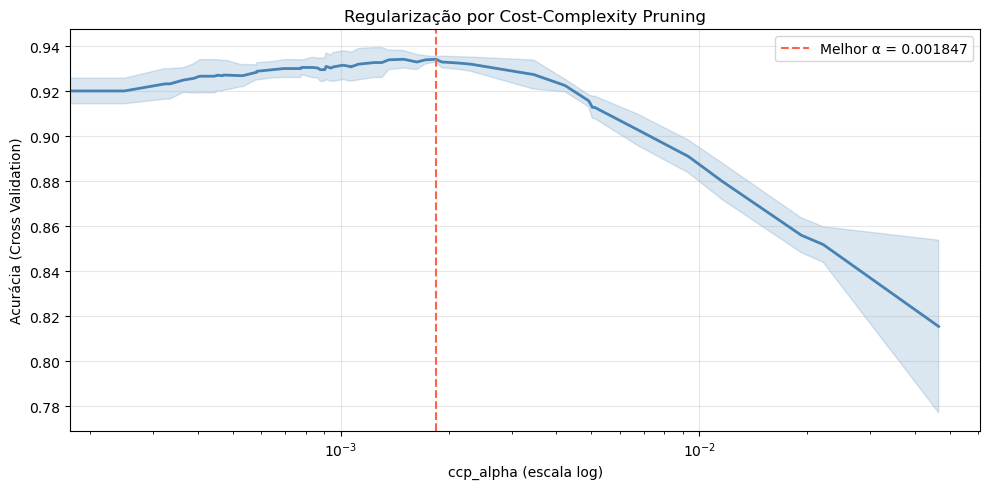

In [31]:
from sklearn.model_selection import cross_val_score

# -------------------------------------------------------------
# ETAPA 2 — Minimal Cost-Complexity Pruning
# -------------------------------------------------------------

# Obter os valores candidatos de alpha
path = tree_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]  # remove o último (árvore vazia)

print(f"Número de alphas candidatos: {len(ccp_alphas)}")
print(f"Range de alpha: {ccp_alphas.min():.6f} até {ccp_alphas.max():.6f}")

# Cross Validation para cada alpha
# O fold é definido pela dimensão do conjunto de treino
# Usamos k=5 (padrão robusto e bem justificável)
k = 5
scores_mean = []
scores_std  = []

for alpha in ccp_alphas:
    tree_cv = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    scores = cross_val_score(tree_cv, X_train, y_train,
                             cv=k, scoring='accuracy')
    scores_mean.append(scores.mean())
    scores_std.append(scores.std())

scores_mean = np.array(scores_mean)
scores_std  = np.array(scores_std)

# Melhor alpha
best_idx   = scores_mean.argmax()
best_alpha = ccp_alphas[best_idx]

print(f"\nMelhor alpha: {best_alpha:.6f}")
print(f"Acurácia CV:  {scores_mean[best_idx]:.4f} ± {scores_std[best_idx]:.4f}")

# Gráfico alpha vs acurácia
plt.figure(figsize=(10, 5))
plt.plot(ccp_alphas, scores_mean, color='steelblue', linewidth=2)
plt.fill_between(ccp_alphas,
                 scores_mean - scores_std,
                 scores_mean + scores_std,
                 alpha=0.2, color='steelblue')
plt.axvline(best_alpha, color='tomato', linestyle='--',
            label=f'Melhor α = {best_alpha:.6f}')
plt.xscale('log')
plt.xlabel('ccp_alpha (escala log)')
plt.ylabel('Acurácia (Cross Validation)')
plt.title('Regularização por Cost-Complexity Pruning')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Árvore regularizada (α = 0.001847):
  Profundidade máxima: 12
  Número de folhas:    27
  Ein  (treino):       0.0491
  Eout (validação):    0.0760
  Diferença:           0.0269

=== Métricas da Árvore de Decisão ===
              precision    recall  f1-score   support

  Normal (0)       0.93      0.96      0.95       600
Anomalia (1)       0.91      0.84      0.88       282

    accuracy                           0.92       882
   macro avg       0.92      0.90      0.91       882
weighted avg       0.92      0.92      0.92       882



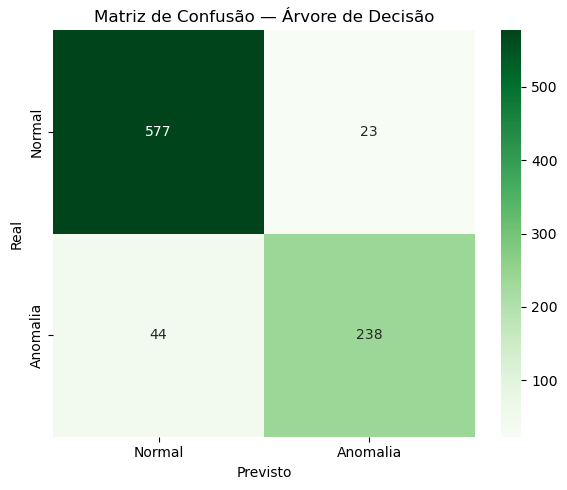

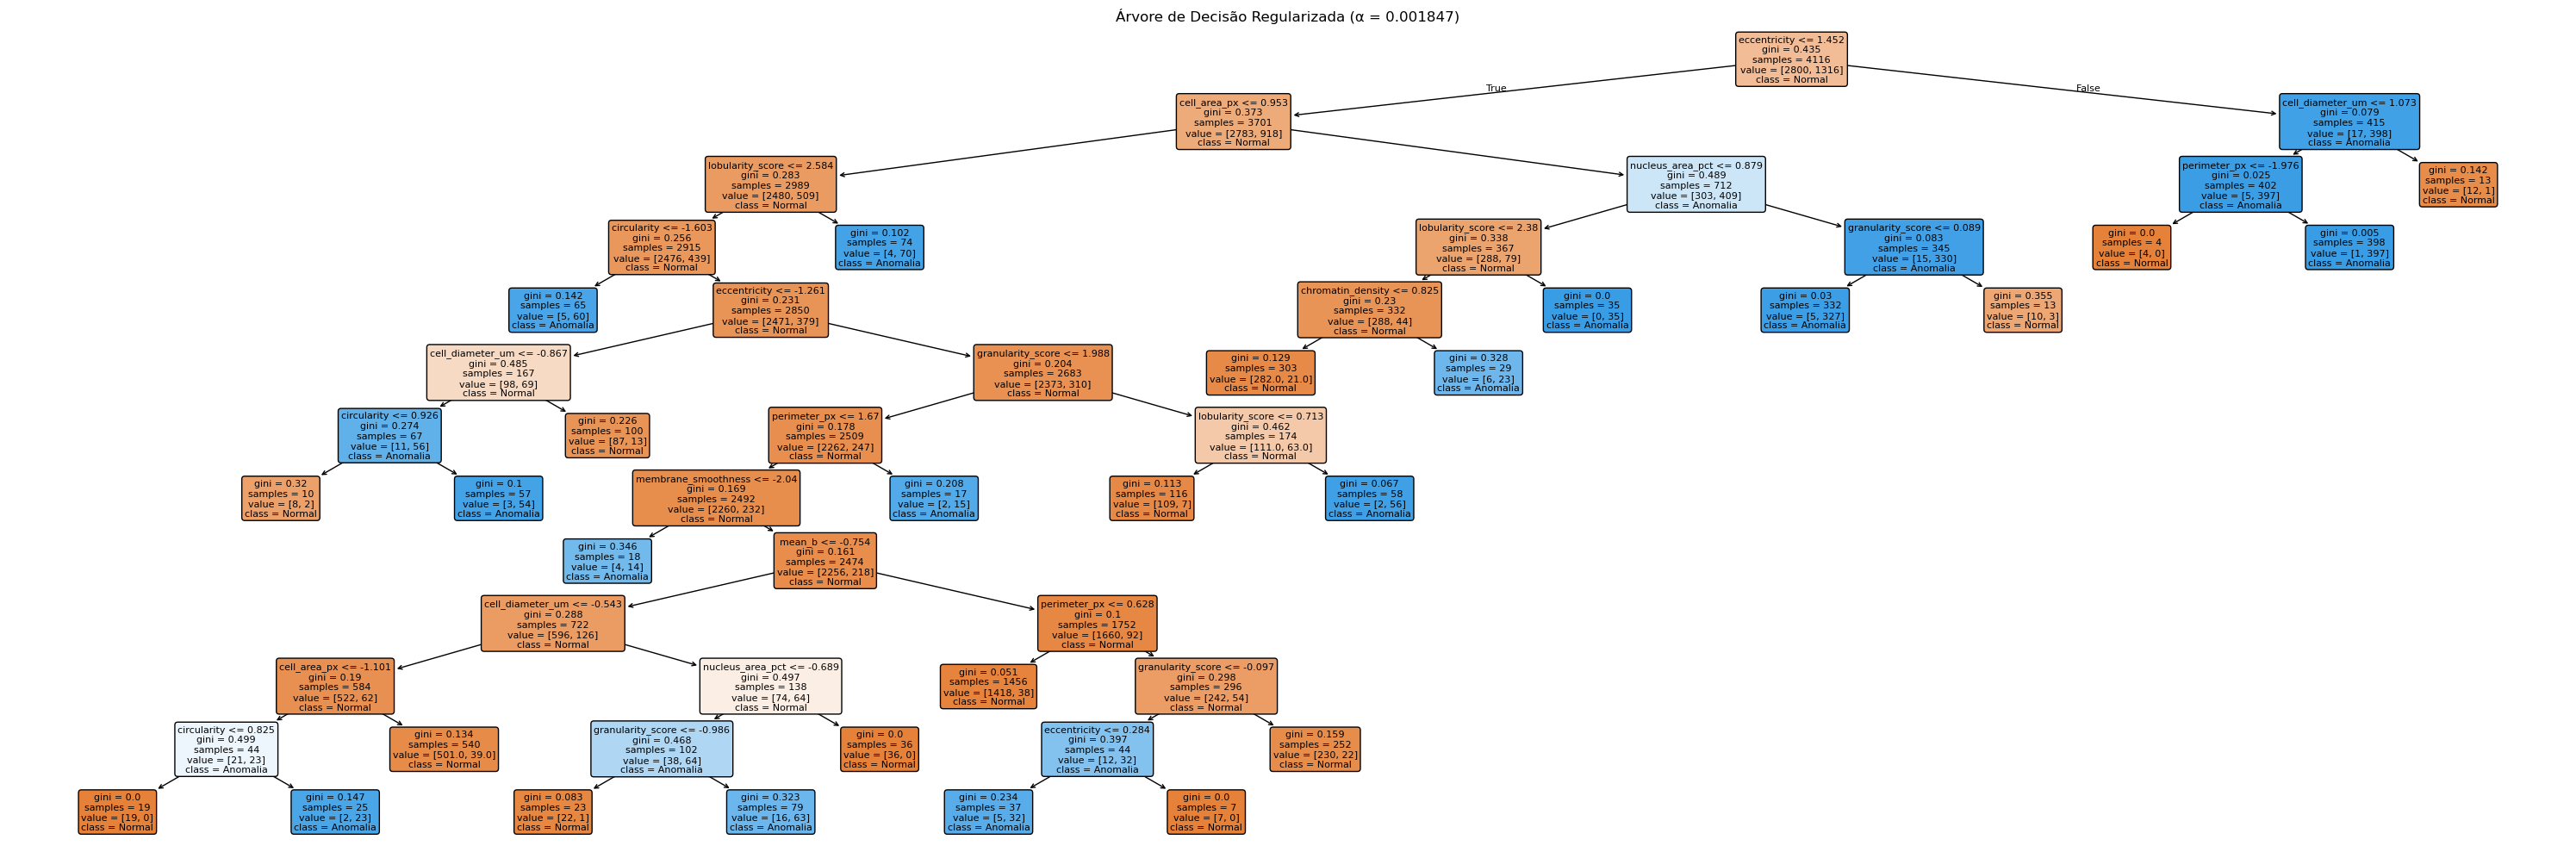

In [32]:
# -------------------------------------------------------------
# ETAPA 3 — Melhor árvore com alpha regularizado
# -------------------------------------------------------------
tree_best = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)
tree_best.fit(X_train, y_train)

ein_best  = 1 - tree_best.score(X_train, y_train)
eout_best = 1 - tree_best.score(X_val,   y_val)

print(f"Árvore regularizada (α = {best_alpha:.6f}):")
print(f"  Profundidade máxima: {tree_best.get_depth()}")
print(f"  Número de folhas:    {tree_best.get_n_leaves()}")
print(f"  Ein  (treino):       {ein_best:.4f}")
print(f"  Eout (validação):    {eout_best:.4f}")
print(f"  Diferença:           {eout_best - ein_best:.4f}")

# -------------------------------------------------------------
# MÉTRICAS FINAIS
# -------------------------------------------------------------
y_pred_tree = tree_best.predict(X_val)

print("\n=== Métricas da Árvore de Decisão ===")
print(classification_report(y_val, y_pred_tree,
      target_names=['Normal (0)', 'Anomalia (1)']))

# Matriz de confusão
cm_tree = confusion_matrix(y_val, y_pred_tree)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Anomalia'],
            yticklabels=['Normal', 'Anomalia'])
plt.title('Matriz de Confusão — Árvore de Decisão')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# PLOTAR A ÁRVORE
# -------------------------------------------------------------
plt.figure(figsize=(30, 10))
plot_tree(tree_best,
          feature_names=X.columns.tolist(),
          class_names=['Normal', 'Anomalia'],
          filled=True,
          rounded=True,
          fontsize=8)
plt.title(f'Árvore de Decisão Regularizada (α = {best_alpha:.6f})')
plt.tight_layout()
plt.show()